In [1]:
# # XGBoost Time-Series Forecasting Framework

# This notebook builds an XGBoost model for time-series forecasting.

# XGBoost does not understand time automatically, so we create:

# - cyclical time features
# - lag features
# - rolling window features
# - interaction features
# - time-series cross-validation

In [2]:
# import libraries

import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [3]:
# load data

df = pd.read_csv('../preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])

df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"

FileNotFoundError: [Errno 2] No such file or directory: '../preprocessed_data.csv'

In [ ]:
# Prevent leakage from other electricity prices

price_cols = [
    c for c in df.columns
    if "el_price" in c and c != target_col
]

for col in price_cols:
    df[col] = df[col].shift(24)

In [ ]:
# Remove only rows created by shifting
df = df.dropna(subset=price_cols).reset_index(drop=True)

In [ ]:
print("XGBoost dataframe shape:", df.shape)
print("Shifted price columns:", len(price_cols))

XGBoost dataframe shape: (52561, 81)
Shifted price columns: 8


In [ ]:
print("Rows before:", len(df))

df = df.dropna(subset=price_cols)

print("Rows after:", len(df))
print("Rows removed:", len_before - len(df))

Rows before: 52561
Rows after: 52561
Rows removed: 0


In [ ]:
df = df.ffill()

In [ ]:
# ## 2. Create cyclical time features

# Time is cyclical.

# For example:

# - hour 23 and hour 0 are close to each other
# - December and January are close to each other

# So instead of using only raw hour/month numbers, we use sine and cosine features.

In [ ]:
# Create cyclical time features

import numpy as np

# Basic time components
df["hour"] = df["datetime_utc12"].dt.hour
df["dayofweek"] = df["datetime_utc12"].dt.dayofweek
df["month"] = df["datetime_utc12"].dt.month
df["dayofyear"] = df["datetime_utc12"].dt.dayofyear

# Weekend indicator
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# -----------------------------
# Cyclical encoding
# -----------------------------

# Hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Time features created successfully.")

Time features created successfully.


In [ ]:
# Create target lag features: daily, weekly, yearly

# Daily lag: same hour yesterday
df["target_lag_24h"] = df[target_col].shift(24)

# Weekly lag: same hour last week
df["target_lag_168h"] = df[target_col].shift(168)

# Yearly lag: same hour last year
df["target_lag_8760h"] = df[target_col].shift(8760)

print("Target lag features created.")
print(df[["target_lag_24h", "target_lag_168h", "target_lag_8760h"]].isna().sum())

Target lag features created.
target_lag_24h        24
target_lag_168h      168
target_lag_8760h    8760
dtype: int64


In [ ]:
# Leakage-safe rolling window features

# -----------------------------------
# Daily rolling features (24h)
# -----------------------------------

df["rolling_mean_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df["rolling_std_24h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=24)
    .std()
)

# -----------------------------------
# Weekly rolling features (168h)
# -----------------------------------

df["rolling_mean_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .mean()
)

df["rolling_std_168h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=168)
    .std()
)

# -----------------------------------
# Yearly rolling features (8760h)
# -----------------------------------

df["rolling_mean_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .mean()
)

df["rolling_std_8760h"] = (
    df[target_col]
    .shift(1)
    .rolling(window=8760)
    .std()
)

print("Rolling window features created successfully.")

print(df[[
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_mean_8760h"
]].isna().sum())

Rolling window features created successfully.
rolling_mean_24h        24
rolling_mean_168h      168
rolling_mean_8760h    8760
dtype: int64


In [ ]:
# Check missing values before final cleanup

missing_summary = df.isna().sum()

missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.sort_values(ascending=False).head(20))

target_lag_8760h      8760
rolling_mean_8760h    8760
rolling_std_8760h     8760
target_lag_168h        168
rolling_mean_168h      168
rolling_std_168h       168
target_lag_24h          24
rolling_mean_24h        24
rolling_std_24h         24
dtype: int64


In [ ]:
# Final cleanup after all feature engineering

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleanup: 52561
Rows after cleanup: 43801
Rows removed: 8760


In [ ]:
# Define target

target_col = "el_price_dol_MWh_OTA2201"

# Exclude non-feature columns

exclude_cols = [
    "datetime_utc12",
    target_col
]

# Create feature list

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

# Define X and y

X = df[feature_cols]

y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_cols))

Feature matrix shape: (43801, 99)
Target shape: (43801,)
Number of features: 99


In [ ]:
# Check missing values before final cleanup

missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

print(missing_summary.sort_values(ascending=False).head(30))

Series([], dtype: int64)


In [ ]:
# Final cleanup after all feature engineering

rows_before = len(df)

df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Rows before cleanup: {rows_before}")
print(f"Rows after cleanup: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleanup: 43801
Rows after cleanup: 43801
Rows removed: 0


In [ ]:
# Define target and features

target_col = "el_price_dol_MWh_OTA2201"

exclude_cols = [
    "datetime_utc12",
    target_col
]

feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_cols))

Feature matrix shape: (43801, 99)
Target shape: (43801,)
Number of features: 99


In [ ]:
# -----------------------------------
# Time-based Train/Test Split
# -----------------------------------

split_ratio = 0.8

split_index = int(len(df) * split_ratio)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain period:")
print(df["datetime_utc12"].iloc[0], "to",
      df["datetime_utc12"].iloc[split_index - 1])

print("\nTest period:")
print(df["datetime_utc12"].iloc[split_index], "to",
      df["datetime_utc12"].iloc[-1])

Train shape: (35040, 99)
Test shape: (8761, 99)

Train period:
2020-01-02 00:00:00 to 2023-12-31 23:00:00

Test period:
2024-01-01 00:00:00 to 2024-12-31 00:00:00


In [ ]:
# Train XGBoost model

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# Make predictions

y_pred = xgb_model.predict(X_test)

print("Predictions completed.")
print(y_pred[:10])

Predictions completed.
[28.041147  29.433744  19.034956  21.900984   1.0296822  8.531873
 16.620922  38.42942   57.43101   58.027863 ]


In [ ]:
# Evaluate model performance

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 50.4956
RMSE : 112.3884
R²   : 0.6443


In [ ]:
# Time-series cross validation

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    # Split data
    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    # Train model
    model_cv = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_cv.fit(X_train_cv, y_train_cv)

    # Predict
    y_pred_cv = model_cv.predict(X_test_cv)

    # Metrics
    mae = mean_absolute_error(y_test_cv, y_pred_cv)

    rmse = np.sqrt(
        mean_squared_error(y_test_cv, y_pred_cv)
    )

    r2 = r2_score(y_test_cv, y_pred_cv)

    # Store results
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"\nFold {fold}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    fold += 1


Fold 1
MAE  : 54.5020
RMSE : 82.7824
R²   : 0.4750

Fold 2
MAE  : 33.0904
RMSE : 51.1957
R²   : 0.6753

Fold 3
MAE  : 41.7454
RMSE : 67.0167
R²   : 0.4954

Fold 4
MAE  : 40.7036
RMSE : 79.1208
R²   : 0.5114

Fold 5
MAE  : 56.0193
RMSE : 126.9396
R²   : 0.6008


In [ ]:
print("\nAverage Cross-Validation Results")

print(f"Average MAE  : {np.mean(mae_scores):.4f}")
print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
print(f"Average R²   : {np.mean(r2_scores):.4f}")


Average Cross-Validation Results
Average MAE  : 45.2121
Average RMSE : 81.4110
Average R²   : 0.5516


In [ ]:
# Feature importance

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                       feature  importance
93            rolling_mean_24h    0.156792
4     el_price_dol_MWh_KIK2201    0.154967
5     el_price_dol_MWh_RDF2201    0.099427
9                       Diesel    0.058869
90              target_lag_24h    0.050519
2     el_price_dol_MWh_INV2201    0.016308
3     el_price_dol_MWh_ISL2201    0.016169
70              demand_GWh_USI    0.015547
13                       Hydro    0.014322
45        SI_TKA__lake_level_m    0.013896
69              demand_GWh_UNI    0.013812
97          rolling_mean_8760h    0.012696
8                         Coal    0.012258
43             tauranga_temp_c    0.011399
11                         Gas    0.011289
46  SI_TKA__active_storage_mm³    0.011062
51        NI_WKA__lake_level_m    0.010751
39             auckland_temp_c    0.010584
66              demand_GWh_CNI    0.010547
68              demand_GWh_LSI    0.010497


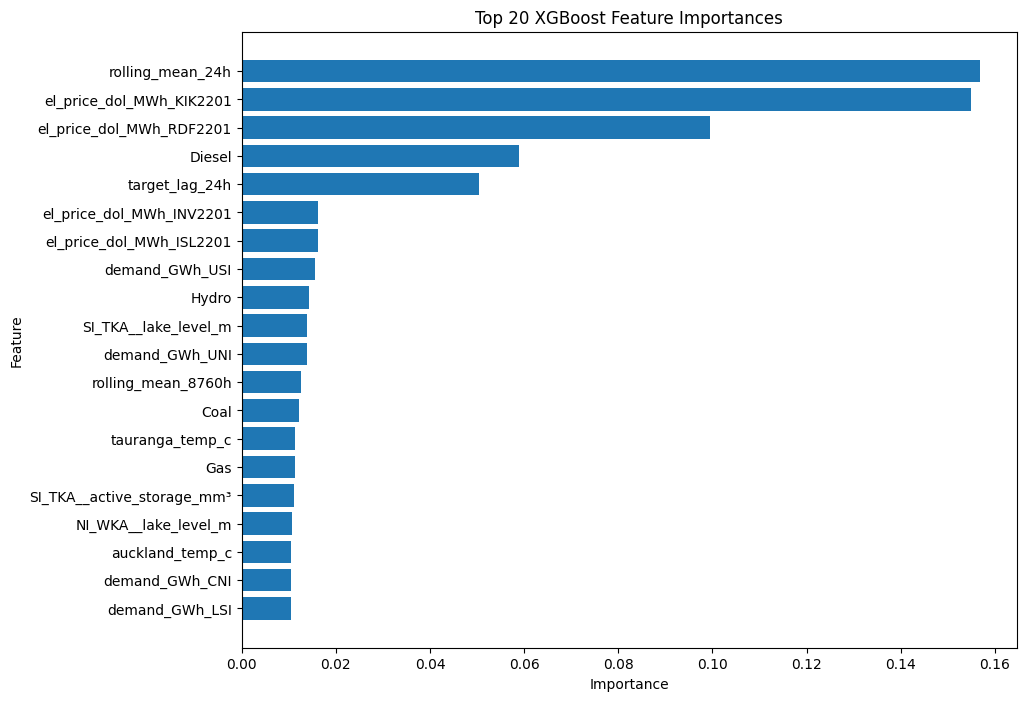

In [ ]:
import matplotlib.pyplot as plt

# Top 20 feature importance

top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 20 XGBoost Feature Importances")

plt.show()

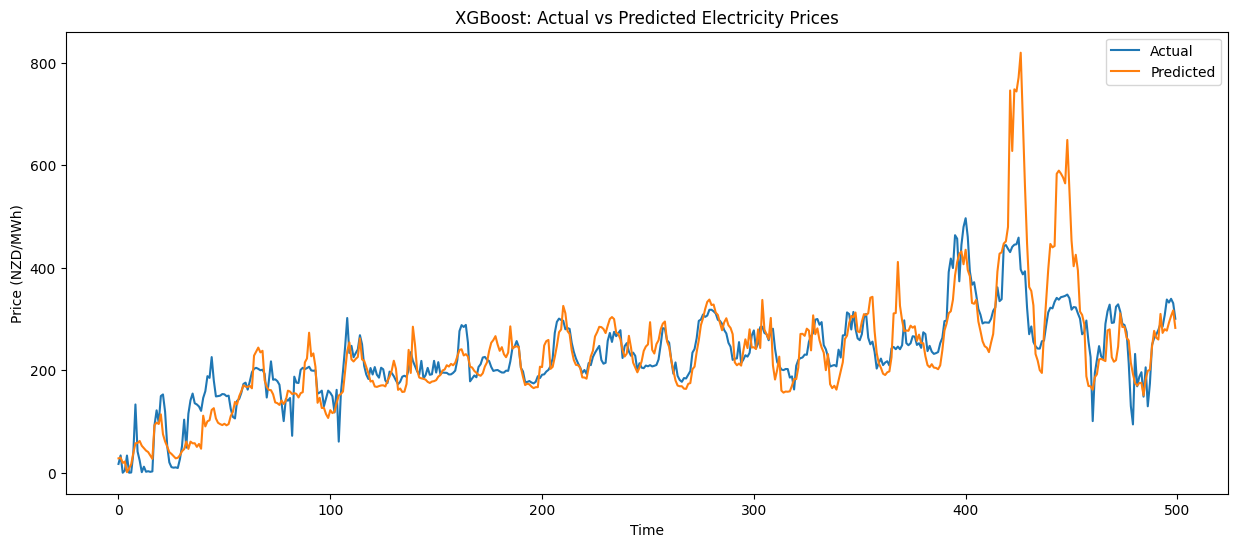

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predicted

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="Predicted"
)

plt.title("XGBoost: Actual vs Predicted Electricity Prices")
plt.xlabel("Time")
plt.ylabel("Price (NZD/MWh)")

plt.legend()

plt.show()

In [ ]:
# XGBoost with early stopping

xgb_early = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)

xgb_early.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Best iteration:")
print(xgb_early.best_iteration)

Best iteration:
128


In [ ]:
# Predictions

y_pred_early = xgb_early.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Store R² scores
train_r2 = []
test_r2 = []

# Evaluate R² at each boosting round

for i in range(1, xgb_model_curve.n_estimators + 1):

    # Training predictions
    y_train_pred = xgb_model_curve.predict(
        X_train,
        iteration_range=(0, i)
    )

    # Testing predictions
    y_test_pred = xgb_model_curve.predict(
        X_test,
        iteration_range=(0, i)
    )

    # Calculate R²
    train_r2.append(
        r2_score(y_train, y_train_pred)
    )

    test_r2.append(
        r2_score(y_test, y_test_pred)
    )

print("R² learning curve calculated.")

R² learning curve calculated.


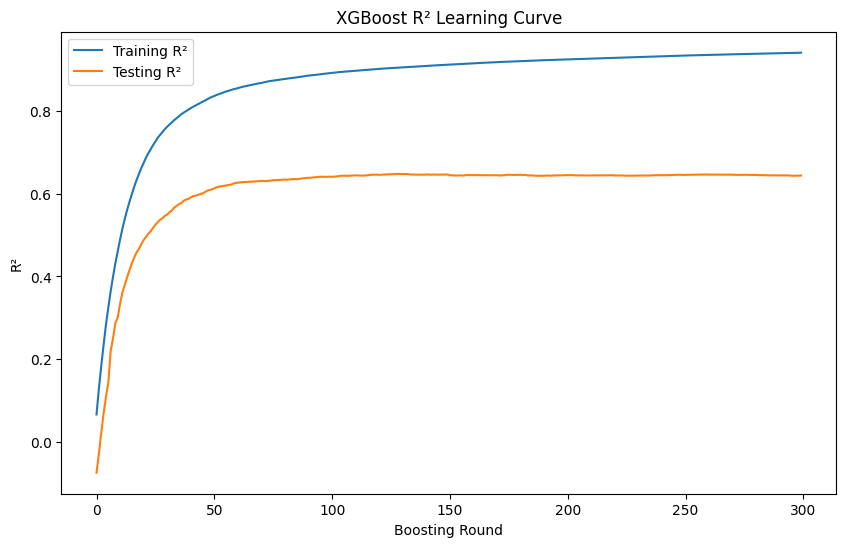

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    train_r2,
    label="Training R²"
)

plt.plot(
    test_r2,
    label="Testing R²"
)

plt.xlabel("Boosting Round")
plt.ylabel("R²")

plt.title("XGBoost R² Learning Curve")

plt.legend()

plt.show()